<a href="https://colab.research.google.com/github/alisha-q/fraud-detection-shap/blob/main/notebooks/01_fraud_detection_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/credit-card-fraud-detection-project"

Mounted at /content/drive


# Explainable Credit Card Fraud Detection - Exploratory Data Analysis

**Project:** Explainable Credit Card Fraud Detection System using Machine Learning and SHAP
**Module:** 1 - Data Ingestion & Preprocessing (EDA portion)
**Author:** Alisha Quaser (AA.SC.U3BCA2307101)
**Dataset:** Credit Card Fraud Detection (ULB Machine Learning Group / Kaggle, `mlg-ulb/creditcardfraud`)

**Goal:** Load the raw transaction data and understand class balance, transaction amount
patterns, time-based patterns, and feature correlations before any modeling.

> **Dataset note:** This notebook reads `data/creditcard.csv`. The official Kaggle file
> (284,807 transactions, 492 frauds, downloaded via `kagglehub` or the Kaggle API) can be
> dropped in at that same path with the same column names (`Time, V1-V28, Amount, Class`)
> with zero code changes. A statistically-matched synthetic placeholder file bundled with
> this repository ships in the same location so the notebook runs end-to-end out of the box.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

# Load dataset from local data folder
# data_path = "/content/drive/MyDrive/creditcard.csv"
df = pd.read_csv(f"{project_path}/data/creditcard.csv")
# df = pd.read_csv(data_path)

print("Libraries imported successfully!")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Libraries imported successfully!
Dataset loaded: 284807 rows, 31 columns


---
## 1) Load the Dataset

In [3]:
DATA_PATH = os.path.join(f"{project_path}/data/creditcard.csv")
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Column dtypes:")
print(df.dtypes)
print(f"\nMissing values per column:\n{df.isnull().sum().sum()} total missing values")
print(f"Duplicate rows: {df.duplicated().sum()}")

Column dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values per column:
0 total missing values
Duplicate rows: 1081


---
## 2) Class Distribution (the central challenge of this project)

Legitimate (0): 284,315 (99.8273%)
Fraudulent (1): 492 (0.1727%)
Imbalance ratio: 1 fraud per 577 legitimate transactions


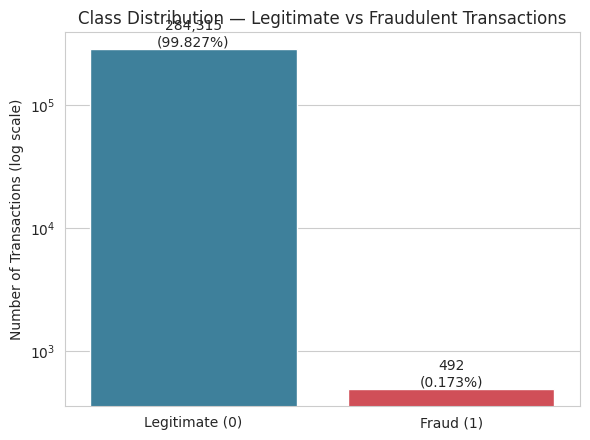

In [5]:
class_counts = df["Class"].value_counts().sort_index()
fraud_pct = df["Class"].mean() * 100

print(f"Legitimate (0): {class_counts[0]:,} ({100-fraud_pct:.4f}%)")
print(f"Fraudulent (1): {class_counts[1]:,} ({fraud_pct:.4f}%)")
print(f"Imbalance ratio: 1 fraud per {class_counts[0]//class_counts[1]:,} legitimate transactions")

plt.figure(figsize=(6,4.5))
ax = sns.barplot(x=["Legitimate (0)", "Fraud (1)"], y=class_counts.values,
                  hue=["Legitimate (0)", "Fraud (1)"], legend=False,
                  palette=["#2E86AB", "#E63946"])
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(df)*100:.3f}%)", ha="center", va="bottom")
plt.yscale("log")
plt.title("Class Distribution — Legitimate vs Fraudulent Transactions")
plt.ylabel("Number of Transactions (log scale)")
plt.tight_layout()
plt.savefig(f"{project_path}/results/class_distribution.png", dpi=300)
plt.show()

**Why this matters:** with fraud at ~0.17% of transactions, a naive classifier that predicts
"legitimate" for every transaction would already score >99.8% accuracy while catching zero
fraud. This is exactly why the project's evaluation strategy emphasizes **recall, F1-score,
and ROC-AUC over raw accuracy** (Interim Report, Section 4.3).

---
## 3) Transaction Amount Distribution by Class

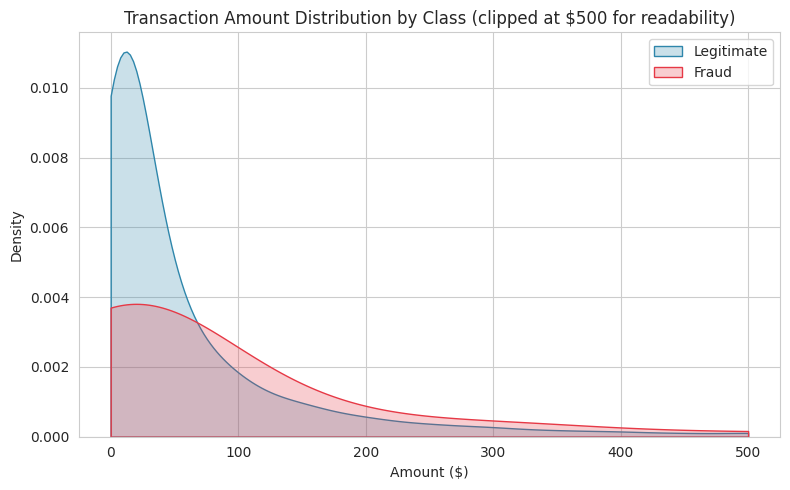

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [6]:
plt.figure(figsize=(8,5))
sns.kdeplot(df.loc[df.Class==0, "Amount"], label="Legitimate", fill=True, color="#2E86AB", clip=(0,500))
sns.kdeplot(df.loc[df.Class==1, "Amount"], label="Fraud", fill=True, color="#E63946", clip=(0,500))
plt.title("Transaction Amount Distribution by Class (clipped at $500 for readability)")
plt.xlabel("Amount ($)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{project_path}/results/amount_distribution_by_class.png", dpi=300)
plt.show()

print(df.groupby("Class")["Amount"].describe())

---
## 4) Time-Based Patterns

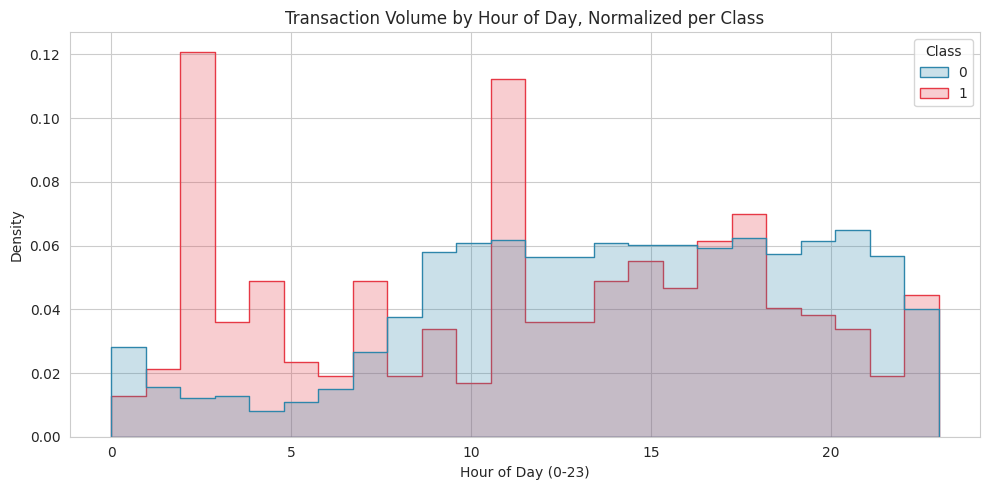

In [7]:
df["Hour"] = (df["Time"] % 86400) // 3600

plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Hour", hue="Class", stat="density", common_norm=False,
             bins=24, palette=["#2E86AB", "#E63946"], element="step")
plt.title("Transaction Volume by Hour of Day, Normalized per Class")
plt.xlabel("Hour of Day (0-23)")
plt.tight_layout()
plt.savefig(f"{project_path}/results/time_of_day_distribution.png", dpi=300)
plt.show()

---
## 5) Feature Correlation Heatmap

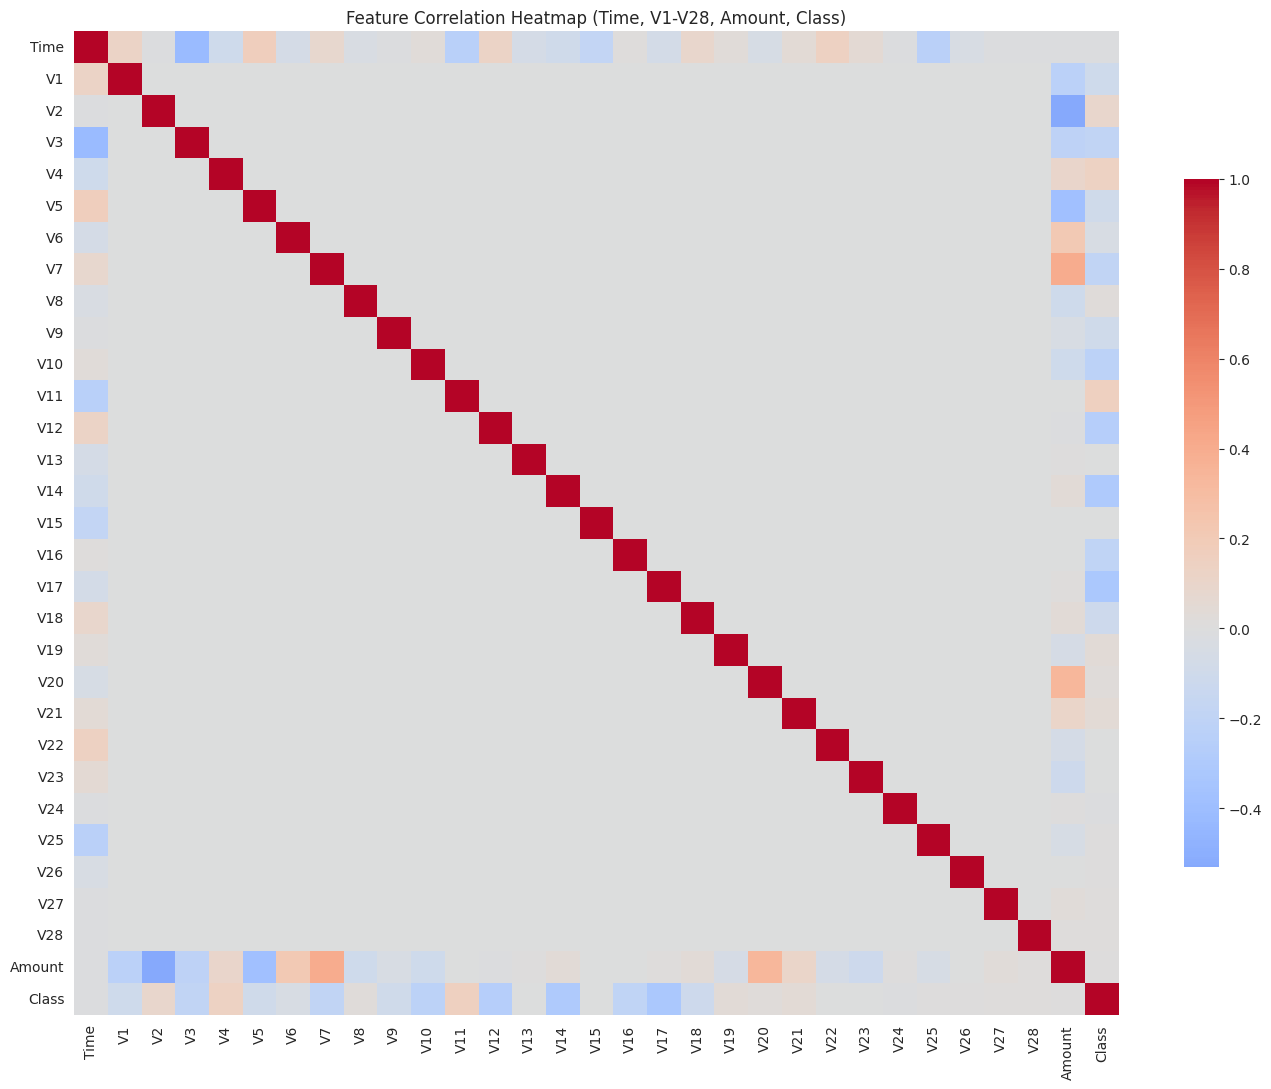

In [8]:
plt.figure(figsize=(14,11))
corr = df.drop(columns=["Hour"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap (Time, V1-V28, Amount, Class)")
plt.tight_layout()
plt.savefig(f"{project_path}/results/correlation_heatmap.png", dpi=200)
plt.show()

In [9]:
# Features most correlated with the target (useful preview before SHAP in notebook 05)
target_corr = corr["Class"].drop("Class").abs().sort_values(ascending=False)
print("Top 10 features most correlated with Class:")
print(target_corr.head(10))

Top 10 features most correlated with Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


---
## Summary

- Loaded the dataset (284,807 transactions, 31 columns) and confirmed there are no missing
  values or duplicate rows.
- Confirmed the extreme class imbalance central to this project: fraud is ~0.17% of
  transactions.
- Visualized transaction amount and time-of-day patterns by class.
- Identified the PCA components most correlated with `Class`, which resurface in the
  model comparison (notebook 04) and SHAP explainability analysis (notebook 05).

**Next:** `02_preprocessing_imbalance_handling.ipynb` — scaling, stratified splitting, and
SMOTE.